In [1]:
import os
import sys
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt
import matplotlib
from MDAnalysis.analysis import align
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 100

# The line of code sets the default resolution for plots created using matplotlib, specifically for figures. 
# The default value for figure.dpi is 100, meaning that each inch of the figure is 100 pixels wide and 100 pixels tall.

In [2]:
sys.path.append('/media/chris/HV620S/MD_Simulations/Pendrin/Human')
# This line of code appends a new directory to the system path in Python. 
# The system path is a list of directories that Python searches for modules to import.

In [3]:
from TrajectoryPCA import TrajectoryPCA

In [153]:
# This is an example with ATG4B system ( 2776 heavy atoms )

#path = '/media/chris/HV620S/MD_Simulations/Pendrin/Human/WT'
#model = mda.Universe(os.path.join(path,'pendrin_md_0ns.pdb'), os.path.join(path,'pendrin_md_0.5us.dcd'))
#residue_indices = [42, 43, 44, 46, 47, 48, 49, 50, 69, 71, 72, 129, 130, 131, 132, 168, 169, 170, 172, 173, 194, 195, 197, 198, 201, 202, 203, 205, 206]
#selection_string = ' or '.join(f'resid {idx}' for idx in residue_indices)
#protein = model.select_atoms('protein and segid B and resid 88:108 110:130 136:156 192:212 345:365 385:405 422:442 and backbone') Core residues
#protein = model.select_atoms('protein and segid B and resid 219:239 264:284 296:316 449:469 487:507 and backbone')

#x_ray_1 = mda.Universe(os.path.join(path,'../7wl9.pdb'))
#x_ray_selected_1 = x_ray_1.select_atoms('protein and segid A and resid 219:239 264:284 296:316 449:469 487:507 and backbone')

#x_ray_2 = mda.Universe(os.path.join(path,'../7wl9.pdb'))
#x_ray_selected_2 = x_ray_2.select_atoms('protein and segid B and resid 219:239 264:284 296:316 449:469 487:507 and backbone')

/home/chris/.local/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:434: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to zeros.
  warnings.warn("1 A^3 CRYST1 record,"


In [85]:
# This is an example with ATG4B system ( 2776 heavy atoms )

path = '/media/chris/HV620S/MD_Simulations/Pendrin/Human/C565Y'
model = mda.Universe(os.path.join(path,'pendrin_c565y_md_0ns_wo_mem.pdb'), os.path.join(path,'pendrin_c565y_md_0.5us_wo_mem.dcd'))
#residue_indices = [42, 43, 44, 46, 47, 48, 49, 50, 69, 71, 72, 129, 130, 131, 132, 168, 169, 170, 172, 173, 194, 195, 197, 198, 201, 202, 203, 205, 206]
#selection_string = ' or '.join(f'resid {idx}' for idx in residue_indices)
#protein = model.select_atoms('protein and segid B and resid 88:108 110:130 136:156 192:212 345:365 385:405 422:442 and backbone') Core residues
protein = model.select_atoms('protein and segid B and resid 496:520 and backbone')

x_ray_1 = mda.Universe(os.path.join(path,'../7wl9.pdb'))
x_ray_selected_1 = x_ray_1.select_atoms('protein and segid A and resid 496:520 and backbone')

x_ray_2 = mda.Universe(os.path.join(path,'../7wl9.pdb'))
x_ray_selected_2 = x_ray_2.select_atoms('protein and segid B and resid 496:520 and backbone')

/home/chris/.local/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:434: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to zeros.
  warnings.warn("1 A^3 CRYST1 record,"


In [86]:
protein_PCA = TrajectoryPCA(protein)

In [87]:
newMeanStructure = protein_PCA.superimpose2mean()

1: 0.6417598125497915
2: 0.004839513321863432
3: 0.00011031353266716577
4: 3.2312534992403823e-06
5: 8.313939940530154e-07


In [88]:
cum_explained_var_ratio, pca_components = protein_PCA.getPCA()

In [89]:
pcs, pca_2_components_ = protein_PCA.project2PC12()

# x-ray point for protein

In [90]:
# Initiation variables

x_ray_Position_1 = x_ray_selected_1.positions - protein.center_of_geometry()
R_x_ray, rmsd_x_ray = align.rotation_matrix(x_ray_Position_1, newMeanStructure)
new_x_ray_Position_1 = np.array(R_x_ray.dot(x_ray_Position_1.T).T)

# Reshape (3 x N) to 3N                               
shape = new_x_ray_Position_1.shape
flatPos_x_ray_1 = new_x_ray_Position_1.reshape(shape[0]*shape[1])
flatPos_mean_1 = newMeanStructure.reshape(shape[0]*shape[1])
                               
# Compute the dot products
x_ray_x_1 = flatPos_x_ray_1.dot(pca_2_components_[0])
x_ray_y_1 = flatPos_x_ray_1.dot(pca_2_components_[1])
mean_x_1 = flatPos_mean_1.dot(pca_2_components_[0])
mean_y_1 = flatPos_mean_1.dot(pca_2_components_[1])

new_x_ray_x_1 = x_ray_x_1 - mean_x_1
new_x_ray_y_1 = x_ray_y_1 - mean_y_1

# Format the results to two decimal places and convert to strings
x_formatted_1 = '%.2f' % new_x_ray_x_1
y_formatted_1 = '%.2f' % new_x_ray_y_1

# Print the formatted results
print(f"x: {x_formatted_1}")
print(f"y: {y_formatted_1}")

x: -1.97
y: 2.49


In [91]:
# Initiation variables

x_ray_Position_2 = x_ray_selected_2.positions - protein.center_of_geometry()
R_x_ray, rmsd_x_ray = align.rotation_matrix(x_ray_Position_2, newMeanStructure)
new_x_ray_Position_2 = np.array(R_x_ray.dot(x_ray_Position_2.T).T)

# Reshape (3 x N) to 3N                               
shape = new_x_ray_Position_2.shape
flatPos_x_ray_2 = new_x_ray_Position_2.reshape(shape[0]*shape[1])
flatPos_mean_2 = newMeanStructure.reshape(shape[0]*shape[1])
                               
# Compute the dot products
x_ray_x_2 = flatPos_x_ray_2.dot(pca_2_components_[0])
x_ray_y_2 = flatPos_x_ray_2.dot(pca_2_components_[1])
mean_x_2 = flatPos_mean_2.dot(pca_2_components_[0])
mean_y_2 = flatPos_mean_2.dot(pca_2_components_[1])

new_x_ray_x_2 = x_ray_x_2 - mean_x_2
new_x_ray_y_2 = x_ray_y_2 - mean_y_2

# Format the results to two decimal places and convert to strings
x_formatted_2 = '%.2f' % new_x_ray_x_2
y_formatted_2 = '%.2f' % new_x_ray_y_2

# Print the formatted results
print(f"x: {x_formatted_2}")
print(f"y: {y_formatted_2}")

x: -3.97
y: 2.57


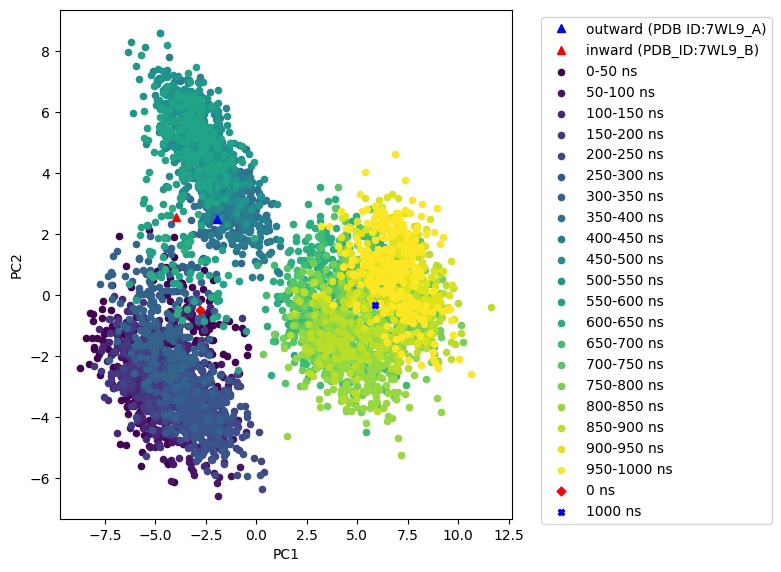

In [92]:
import matplotlib.cm as cm

plt.figure(figsize=(8,6))
#Plot the experimentally resolved or predicted structure on the PCA space
plt.plot(new_x_ray_x_1, new_x_ray_y_1, '^', color='blue', label='outward (PDB ID:7WL9_A)')
plt.plot(new_x_ray_x_2, new_x_ray_y_2, '^', color='red', label='inward (PDB_ID:7WL9_B)')

# Total frames
n_frames = len(pcs)

# Define number of segments (10 segments for 100 ns, 10 ns each)
n_segments = 20
frames_per_segment = n_frames // n_segments

# Create a colormap with 10 colors
colors = cm.viridis(np.linspace(0, 1, n_segments))

# Plot each segment with a different color
for seg in range(n_segments):
    start = 1 + seg * frames_per_segment  # start after first frame
    end = n_frames - 1 if seg == n_segments - 1 else 1 + (seg + 1) * frames_per_segment  # end before last frame
    plt.scatter(pcs[start:end, 0], pcs[start:end, 1], color=colors[seg], s=20, label=f'{seg*50}-{(seg+1)*50} ns')
    
plt.scatter(pcs[0, 0], pcs[0, 1], color='red', s=20, marker='D', label='0 ns')  # Diamond for first frame
plt.scatter(pcs[-1, 0], pcs[-1, 1], color='blue', s=20, marker='X', label='1000 ns')  # X for last frame

plt.xlabel('PC1')
plt.ylabel('PC2')
#plt.title('PCA space colored by 10 ns intervals')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(path, 'frames_pca_time_chainB_TM14_mut.png'), dpi=600)
plt.show()


# Plot RMSD with different frames subject to first frame (or mean frame) along the simulations

In [9]:
# These value may be changed to fit your need.

n_frames = 1000
n_ns = 100
inter_space_in_ns = 20

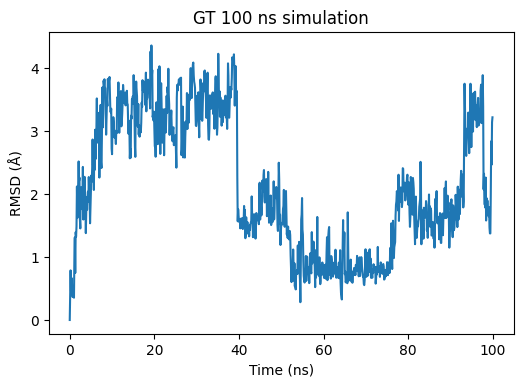

In [10]:
plt.plot(protein_PCA.getRMSD())
plt.xticks(np.arange(0,n_frames + 10, inter_space_in_ns * n_frames / n_ns), np.arange(0,n_ns + 1, inter_space_in_ns))
plt.xlabel('Time (ns)')
plt.ylabel('RMSD (Å)')
plt.title('GT %d ns simulation' %n_ns);
plt.savefig(os.path.join(path,'RMSD GT 100ns MD'),dpi=600)

# Plot the cum_explained_var_ratio curve

This can help understand whether chosing two PCA components can explain data well or not.

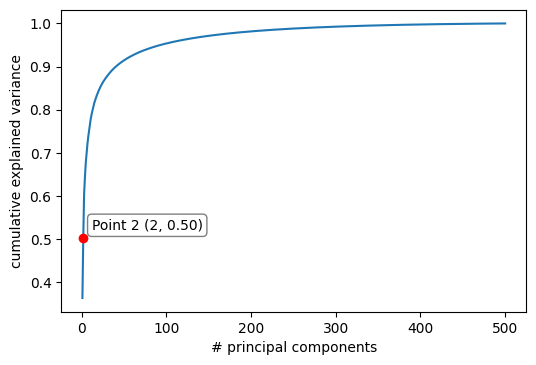

In [17]:
import matplotlib.pyplot as plt

pca_num = range(1, len(cum_explained_var_ratio)+1)
plt.plot(pca_num, cum_explained_var_ratio)
plt.xlabel('# principal components')
plt.ylabel('cumulative explained variance');

# Annotate a specific point in the figure, here we specify the first two principal components explaination value.

index = 2
point = (index, cum_explained_var_ratio[index-1])
plt.plot(point[0], point[1], 'o', color='red')
plt.annotate(f'Point {index} ({index}, {cum_explained_var_ratio[index-1]:.2f})', 
             xy=point, xytext=(index + 10, cum_explained_var_ratio[index-1] + 0.02),
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));

# The second argument, xy, specifies the position of the point on the plot where the annotation will be placed. 
# In this case, the value is point, which is a tuple (index, cum_explained_var_ratio[index]) that represents 
# the x and y values of the point to be annotated.

# The third argument, xytext, specifies the position of the text relative to the point. In this case, the value 
# is (index + 5, cum_explained_var_ratio[index] + 0.05), which places the text to the right and above the point.

# Implement silhouette_avg score to best choose the number of clusters (clustering method = KMeans)

In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

2_clusters_IDs is: [205, 706].
3_clusters_IDs is: [761, 373, 78].
4_clusters_IDs is: [255, 594, 132, 455].
5_clusters_IDs is: [525, 125, 991, 797, 255].
6_clusters_IDs is: [300, 771, 378, 162, 601, 26].
7_clusters_IDs is: [378, 26, 183, 250, 139, 601, 888].
8_clusters_IDs is: [601, 83, 321, 470, 938, 225, 809, 183].
9_clusters_IDs is: [665, 225, 493, 321, 470, 481, 83, 183, 63].
10_clusters_IDs is: [654, 349, 321, 26, 972, 183, 493, 198, 863, 353].


<Figure size 1000x1000 with 0 Axes>

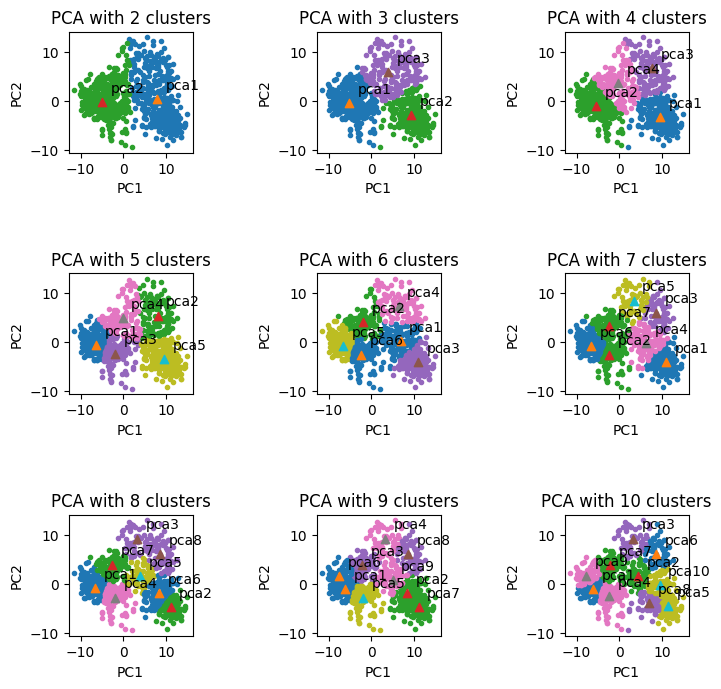

In [13]:
# Plot the silhouette_avg score along different number of clusters

import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 100

n_clusters = 10
silhouette_avg = []

fig = plt.figure(figsize=(10, 10))

# define the number of rows and columns for the grid
fig_x = 3
fig_y = 3
fig_num = fig_x * fig_y

# create a new figure object
fig = plt.figure(figsize=(8, 8))

# set the spacing between the subplots
fig.subplots_adjust(hspace=1, wspace=1)

# loop over each subplot in the grid
for i in range(2, n_clusters + 1):
    kmeans_fit = KMeans(init = 'k-means++', n_clusters = i, n_init = 20).fit(pcs)
    silhouette_avg.append(silhouette_score(pcs, kmeans_fit.labels_))
    
    # add a subplot to the figure
    ax = fig.add_subplot(fig_x, fig_y, i-1)
    
    # plot things on the subplot
    n_clusters_IDs = []
    for j in range(i):
        n_clusters_IDs.append(np.linalg.norm(pcs-kmeans_fit.cluster_centers_[j], axis=1).argmin())
        ax.scatter(pcs.T[0][kmeans_fit.labels_==j], pcs.T[1][kmeans_fit.labels_==j], marker='.')
        ax.scatter(pcs[n_clusters_IDs[j]][0],pcs[n_clusters_IDs[j]][1],marker='^')
        ax.annotate('pca'+str(j+1), [pcs[n_clusters_IDs[j]][0]+2, pcs[n_clusters_IDs[j]][1]+2])
    
    # set the title for the subplot
    ax.set_title(f"PCA with {i} clusters")
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    
    # print n_cluster_IDs
    print(f"{i}_clusters_IDs is: {n_clusters_IDs}.")
    
# show the figure
plt.show()


    
# n_init is the number of times the KMeans algorithm will be run with different 
# centroid seeds. The final results will be the best output of n_init consecutive 
# runs in terms of inertia, i.e., the sum of squared distances of samples to their 
# closest cluster center.

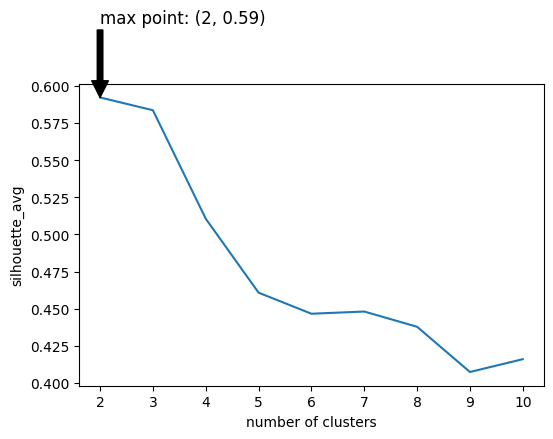

In [14]:
plt.plot(range(2, n_clusters + 1), silhouette_avg)


# The xy parameter specifies the coordinates of the annotated point, and the xytext parameter specifies the 
# coordinates of the text label. The arrowprops parameter adds an arrow pointing to the annotated point. 
# Finally, the fontsize parameter sets the font size of the text label.

kmeans_ymax = max(silhouette_avg)
kmeans_xmax = silhouette_avg.index(kmeans_ymax) + 2
plt.annotate('max point: ({:.0f}, {:.2f})'.format(kmeans_xmax, kmeans_ymax), 
             xy=(kmeans_xmax, kmeans_ymax), 
             xytext=(kmeans_xmax, kmeans_ymax+0.05), 
             arrowprops=dict(facecolor='black', shrink=1), 
             fontsize=12)

plt.xticks(range(2, n_clusters + 1), range(2, n_clusters + 1))
plt.xlabel('number of clusters')
plt.ylabel('silhouette_avg')
plt.savefig(os.path.join(path,'Silhoutte_coefficient.png'),dpi=600)
plt.show()

# For optimal choices of K means

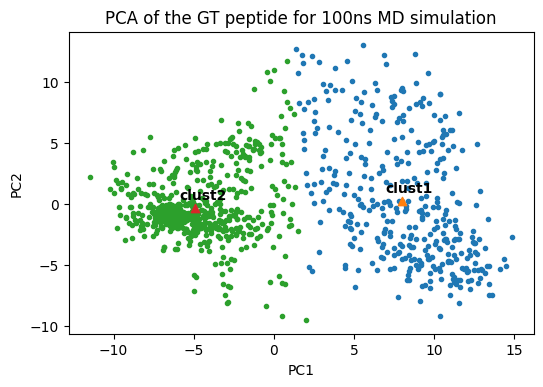

n_clusters_IDs: [205, 706]


In [15]:
from sklearn.cluster import KMeans

n_clusters = kmeans_xmax
n_clusters_IDs = []

kmean = KMeans(init = 'k-means++', n_clusters = n_clusters, n_init = 20).fit(pcs)
#kmean = KMeans(init = 'random', n_clusters = n_clusters, n_init = 'auto').fit(pcs)
#print(kmean)

fig = plt.figure() 
ax = fig.add_subplot(111)
ax.set_title('PCA of the GT peptide for 100ns MD simulation') 

for i in range(n_clusters):
    n_clusters_IDs.append(np.linalg.norm(pcs-kmean.cluster_centers_[i], axis=1).argmin())
    ax.scatter(pcs.T[0][kmean.labels_==i], pcs.T[1][kmean.labels_==i], marker='.')
    ax.scatter(pcs[n_clusters_IDs[i]][0], pcs[n_clusters_IDs[i]][1],marker='^')
    ax.annotate('clust'+str(i+1), [pcs[n_clusters_IDs[i]][0] - 1.0, pcs[n_clusters_IDs[i]][1] + 0.7], fontweight='bold')

plt.xlabel('PC1')
plt.ylabel('PC2')
#plt.plot(new_x_ray_x, new_x_ray_y, '^', color='black', label='model5')
#plt.annotate('model5', xy=point, xytext=(new_x_ray_x - 1.5, new_x_ray_y + 0.7), fontweight='bold');

plt.savefig(os.path.join(path,'pca_clustering.png'),dpi=600)
plt.show() 

print("n_clusters_IDs:", n_clusters_IDs)

#print(pcs-kmean.cluster_centers_[1])


# Select the structure for each cluster  

In [16]:
kmean = KMeans(init = 'random', n_clusters = 2 ).fit(pcs)

clu1ID = np.linalg.norm(pcs - kmean.cluster_centers_[0], axis=1).argmin()

clu2ID = np.linalg.norm(pcs - kmean.cluster_centers_[1], axis=1).argmin()

#clu3ID = np.linalg.norm(pcs - kmean.cluster_centers_[2], axis=1).argmin()

#clu4ID = np.linalg.norm(pcs - kmean.cluster_centers_[3], axis=1).argmin()

protein = model.select_atoms('protein')

model.trajectory[clu1ID]

protein.write(os.path.join(path,'cluster1_new.pdb'))

model.trajectory[clu2ID]

protein.write(os.path.join(path,'cluster2_new.pdb'))

#model.trajectory[clu3ID]

#protein.write(os.path.join(path,'cluster3_new.pdb'))

#model.trajectory[clu4ID]

#protein.write(os.path.join(path,'cluster4_new.pdb'))

/home/chris/.local/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:1026: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/chris/.local/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:1026: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/chris/.local/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:1026: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
/home/chris/.local/lib/python3.8/site-packages/MDAnalysis/coordinates/PDB.py:1026: UserWarning: Found no information for attr: 'tempfactors' Using default value of '0.0'
  warnings.warn("Found no information for attr: '{}'"
/home/chris/.local/lib/python3.8/site-packages/MDAnalysis/core/topologyattrs.py:2011: VisibleDeprecationWarning: Crea

In [21]:
print(f'cluster1:{clu1ID} cluster2:{clu2ID}')

cluster1:783 cluster2:4318
